# Classificação de Gênero em Reviews de Produtos

## Objetivo
Desenvolver um modelo de classificação que prediga o gênero do autor (Masculino/Feminino) a partir do texto de reviews de produtos.

In [2]:
import pandas as pd
import numpy as np
import pickle
import warnings
import re
import unicodedata
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import ComplementNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

True

## 2. Carregamento dos Dados

In [3]:
df = pd.read_csv('/content/treino.csv')
df_validacao = pd.read_csv('/content/validacao.csv')

print(f'Shape do treino: {df.shape}')
print(f'Shape da validação: {df_validacao.shape}')
print(f'\nColunas: {df.columns.tolist()}')
print(f'\nTipos de dados:')
print(df.dtypes)
print(f'\nPrimeiras 5 linhas do treino:')
df.head()

Shape do treino: (76942, 14)
Shape da validação: (25647, 14)

Colunas: ['submission_date', 'reviewer_id', 'product_id', 'product_name', 'product_brand', 'site_category_lv1', 'site_category_lv2', 'review_title', 'overall_rating', 'recommend_to_a_friend', 'review_text', 'reviewer_birth_year', 'reviewer_gender', 'reviewer_state']

Tipos de dados:
submission_date           object
reviewer_id               object
product_id                object
product_name              object
product_brand             object
site_category_lv1         object
site_category_lv2         object
review_title              object
overall_rating             int64
recommend_to_a_friend     object
review_text               object
reviewer_birth_year      float64
reviewer_gender           object
reviewer_state            object
dtype: object

Primeiras 5 linhas do treino:


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-01-25 15:09:27,a06d0380bcd447431774739131312d3532e1018988da8c...,129610281,"iPhone 7 Plus 128GB dourado Tela Retina HD 5,5...",apple,Celulares e Smartphones,Smartphone,Iphone,3,Yes,É Verdade Mesmo Gente Essa Promocao? To queren...,1994.0,F,BA
1,2018-05-14 16:20:25,62bbbab0822b6917233e8a9846dc3e7acbdfe6b4df788a...,120934895,"TV LED 32"" Sony KDL-32R305B HD com Conversor D...",sony,TV e Home Theater,TV,Marca conceituada,3,Yes,"Acredito ser uma Boa TV, não tenho como ava...",1965.0,M,BA
2,2018-05-19 15:43:40,27908d4eea73f655ca4d50adc1c373efccc3b748d4a779...,15844032,Suporte P/ Notebook C/ Cooler Gamer Warrior - ...,NaN,Informática e Acessórios,Peças para Notebook,Excelente aquisição,5,Yes,A compra do produto confirmou a qualidade de o...,1951.0,M,PE
3,2018-01-14 14:35:10,b1ddb4c179231ffb650097bec1ad8033dc8c2bad60a846...,132444050,Smartphone Motorola Moto G 5S Dual Chip Androi...,NaN,Celulares e Smartphones,Smartphone,Atende as necessidades,4,Yes,Celular intermediário de bom custo benefício. ...,1978.0,F,PA
4,2018-03-08 12:40:03,4188541be9484e0e49c4803e767354c3e84e419a2d23da...,132522724,Panela de Pressão Elétrica Digital Philco Pppv...,NaN,Eletroportáteis,Panela Elétrica,Muito bom,4,Yes,"Prática, fácil de limpar, excelente produto. R...",1980.0,F,RJ


## 3. Análise Exploratória dos Dados (EDA)

##3.0. Limpeza de dados nulos

In [4]:
print('='*70)
print('LIMPEZA INICIAL DO DATASET')
print('='*70)

print(f'Shape original: {df.shape}')

df = df.dropna(subset=['review_text'])

df['review_text'] = df['review_text'].astype(str)

df['review_text'] = df['review_text'].str.strip()

df = df[
    df['review_text'].str.lower() != 'nan'
]

print(f'Shape após limpeza: {df.shape}')

print('\nMissing restantes:')
print(df['review_text'].isnull().sum())

LIMPEZA INICIAL DO DATASET
Shape original: (76942, 14)
Shape após limpeza: (75056, 14)

Missing restantes:
0


### 3.1 Análise da Variável Alvo

In [5]:
print('='*70)
print('ANÁLISE DA VARIÁVEL ALVO (reviewer_gender)')
print('='*70)

print(f'\nValores únicos: {df["reviewer_gender"].unique()}')
print(f'\nDistribuição de classes:')
print(df['reviewer_gender'].value_counts())

print(f'\nProporção (%):')
proporcoes = df['reviewer_gender'].value_counts(normalize=True) * 100
print(proporcoes)

ratio = proporcoes['F'] / proporcoes['M']
print(f'\nRatio F/M: {ratio:.2f}')
print(f'Desbalanceamento: {abs(1 - ratio) * 100:.2f}%')

print(f'\n\nMissing Values:')
print(df[['review_text', 'reviewer_gender']].isnull().sum())

ANÁLISE DA VARIÁVEL ALVO (reviewer_gender)

Valores únicos: ['F' 'M']

Distribuição de classes:
reviewer_gender
M    38666
F    36390
Name: count, dtype: int64

Proporção (%):
reviewer_gender
M    51.516201
F    48.483799
Name: proportion, dtype: float64

Ratio F/M: 0.94
Desbalanceamento: 5.89%


Missing Values:
review_text        0
reviewer_gender    0
dtype: int64


### 3.2 Análise do Texto de Reviews

In [6]:
print('\n' + '='*70)
print('ANÁLISE DO TEXTO DE REVIEWS')
print('='*70)

df['text_length'] = df['review_text'].str.len()
df['word_count'] = df['review_text'].str.split().str.len()
df['unique_words'] = df['review_text'].apply(lambda x: len(set(str(x).split())))

print(f'\nComprimento dos textos (caracteres):')
print(df['text_length'].describe())

print(f'\nContagem de palavras:')
print(df['word_count'].describe())

print(f'\nPalavras únicas por review:')
print(df['unique_words'].describe())

print(f'\n\nEstatísticas por Gênero:')
print('\nFeminino:')
print(df[df['reviewer_gender'] == 'F']['word_count'].describe())

print('\nMasculino:')
print(df[df['reviewer_gender'] == 'M']['word_count'].describe())


ANÁLISE DO TEXTO DE REVIEWS

Comprimento dos textos (caracteres):
count    75056.000000
mean       136.484052
std        125.665844
min         45.000000
25%         68.000000
50%         95.000000
75%        155.000000
max       4134.000000
Name: text_length, dtype: float64

Contagem de palavras:
count    75056.000000
mean        22.978150
std         22.070216
min          1.000000
25%         11.000000
50%         16.000000
75%         27.000000
max        795.000000
Name: word_count, dtype: float64

Palavras únicas por review:
count    75056.000000
mean        20.353683
std         16.022268
min          1.000000
25%         11.000000
50%         15.000000
75%         24.000000
max        297.000000
Name: unique_words, dtype: float64


Estatísticas por Gênero:

Feminino:
count    36390.000000
mean        22.153229
std         19.591274
min          1.000000
25%         11.000000
50%         16.000000
75%         26.000000
max        481.000000
Name: word_count, dtype: float64

Mas

### 3.3 Visualizações


Visualizações geradas com sucesso!


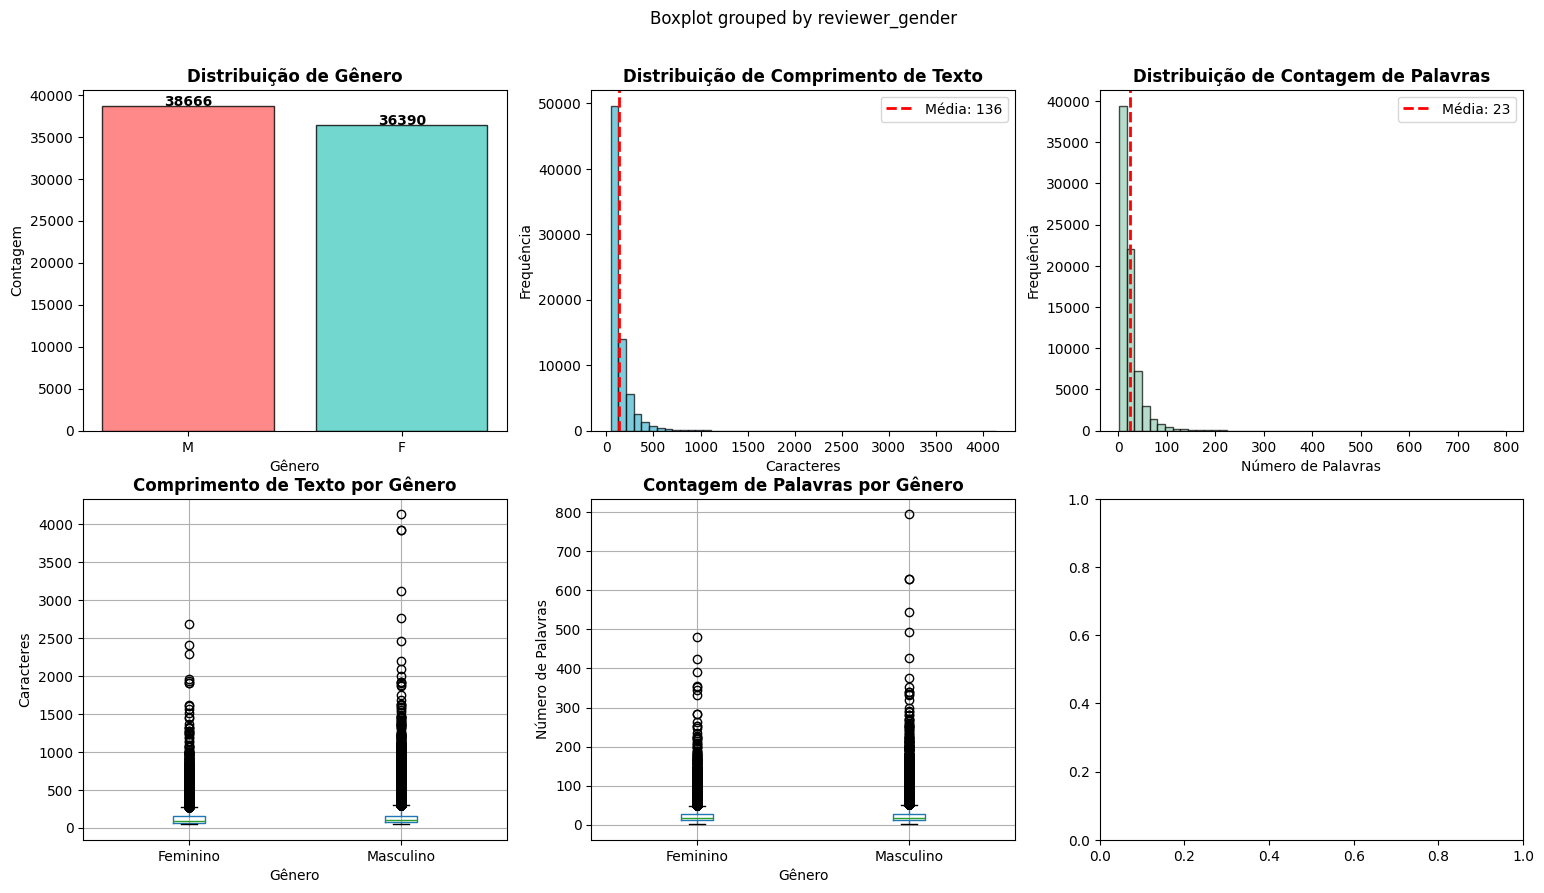

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análise Exploratória dos Dados', fontsize=16, fontweight='bold', y=1.00)

# 1. distribuição de genero
gender_counts = df['reviewer_gender'].value_counts()
colors_gender = ['#FF6B6B', '#4ECDC4']
axes[0, 0].bar(gender_counts.index, gender_counts.values, color=colors_gender, alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Distribuição de Gênero', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Contagem')
axes[0, 0].set_xlabel('Gênero')
for i, v in enumerate(gender_counts.values):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. distribuição de comprimento de texto
axes[0, 1].hist(df['text_length'], bins=50, color='#45B7D1', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribuição de Comprimento de Texto', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Caracteres')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].axvline(df['text_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {df["text_length"].mean():.0f}')
axes[0, 1].legend()

# 3. distribuicao de contagem de palavras
axes[0, 2].hist(df['word_count'], bins=50, color='#96CEB4', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Distribuição de Contagem de Palavras', fontweight='bold', fontsize=12)
axes[0, 2].set_xlabel('Número de Palavras')
axes[0, 2].set_ylabel('Frequência')
axes[0, 2].axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {df["word_count"].mean():.0f}')
axes[0, 2].legend()

# 4. boxplot de comprimento por classe
df.boxplot(column='text_length', by='reviewer_gender', ax=axes[1, 0])
axes[1, 0].set_title('Comprimento de Texto por Gênero', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Gênero')
axes[1, 0].set_ylabel('Caracteres')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Feminino', 'Masculino'])

# 5.boxplot de contagem de palavras por classe
df.boxplot(column='word_count', by='reviewer_gender', ax=axes[1, 1])
axes[1, 1].set_title('Contagem de Palavras por Gênero', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Gênero')
axes[1, 1].set_ylabel('Número de Palavras')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Feminino', 'Masculino'])

print('Visualizações geradas com sucesso!')

## 4. Pré-processamento de Texto


### **4.1** Pipeline de Pré-processamento

In [8]:
def remover_acentos(texto):
    """Remove acentos de um texto."""
    nfkd_form = unicodedata.normalize('NFKD', texto)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

def preprocessar_texto(texto):
    texto = str(texto) if pd.notna(texto) else ''
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    texto = re.sub(r'\S+@\S+', '', texto)
    texto = texto.lower()
    texto = remover_acentos(texto)
    texto = re.sub(r'[^a-z0-9\s]', '', texto)
    texto = re.sub(r'\b\d+\b', '', texto)
    texto = ' '.join(texto.split())

    return texto
df['review_text_processado'] = df['review_text'].apply(preprocessar_texto)
df_validacao['review_text_processado'] = df_validacao['review_text'].apply(preprocessar_texto)


## 5. Representação Textual com TF-IDF

### 5.1 Configuração do Vetorizador

In [9]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.8,
    sublinear_tf=True
)

print(f'\nTF-IDF Vectorizer configurado.')


TF-IDF Vectorizer configurado.


## 6. Preparação dos Dados para Modelagem




In [10]:
df_clean = df[df['review_text_processado'].str.len() > 0].copy()
df_validacao_clean = df_validacao[df_validacao['review_text_processado'].str.len() > 0].copy()

gender_mapping = {'F': 0, 'M': 1}
df_clean['gender_binary'] = df_clean['reviewer_gender'].map(gender_mapping)
df_validacao_clean['gender_binary'] = df_validacao_clean['reviewer_gender'].map(gender_mapping)

X_train = df_clean['review_text_processado']
y_train = df_clean['gender_binary']
X_val = df_validacao_clean['review_text_processado']
y_val = df_validacao_clean['gender_binary']

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

print(f'  Treino shape: {X_train_tfidf.shape}')
print(f'  Validação shape: {X_val_tfidf.shape}')
print(f'  Número de features: {X_train_tfidf.shape[1]}')

  Treino shape: (74994, 40000)
  Validação shape: (25025, 40000)
  Número de features: 40000


## 7. Treinamento e Avaliação dos Modelos

### 7.1 Modelo 1: Regressão Logí­stica

In [11]:

lr_model = LogisticRegression(
    max_iter=2000,
    C=2.0,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_val_tfidf)
y_pred_proba_lr = lr_model.predict_proba(X_val_tfidf)[:, 1]

# Avaliação
acc_lr = accuracy_score(y_val, y_pred_lr)
prec_lr = precision_score(y_val, y_pred_lr)
rec_lr = recall_score(y_val, y_pred_lr)
f1_lr = f1_score(y_val, y_pred_lr)
auc_lr = roc_auc_score(y_val, y_pred_proba_lr)
y_train_pred_lr = lr_model.predict(X_train_tfidf)
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
train_prec_lr = precision_score(y_train, y_train_pred_lr)
train_rec_lr = recall_score(y_train, y_train_pred_lr)
train_f1_lr = f1_score(y_train, y_train_pred_lr)

print('TREINO vs VALIDAÇÃO - LOGISTIC REGRESSION')

print(f'Acurácia TREINO:    {train_acc_lr:.4f}')
print(f'Acurácia VALIDAÇÃO: {acc_lr:.4f}')

print(f'F1 TREINO:          {train_f1_lr:.4f}')
print(f'F1 VALIDAÇÃO:       {f1_lr:.4f}')

print(f'\nGap Accuracy: {(train_acc_lr - acc_lr):.4f}')
print(f'Gap F1:       {(train_f1_lr - f1_lr):.4f}')

print('RESULTADOS - REGRESSÃO LOGÍSTICA')
print(f'Acuráccia:  {acc_lr:.4f}')
print(f'Precision: {prec_lr:.4f}')
print(f'Recall:    {rec_lr:.4f}')
print(f'F1 Score:  {f1_lr:.4f}')
print(f'ROC-AUC:   {auc_lr:.4f}')

print('\nMatriz de Confusão:')
cm_lr = confusion_matrix(y_val, y_pred_lr)
print(cm_lr)

print('\nRelatório de Classificação:')
print(classification_report(y_val, y_pred_lr, target_names=['F', 'M']))

TREINO vs VALIDAÇÃO - LOGISTIC REGRESSION
Acurácia TREINO:    0.8104
Acurácia VALIDAÇÃO: 0.6868
F1 TREINO:          0.8177
F1 VALIDAÇÃO:       0.6993

Gap Accuracy: 0.1236
Gap F1:       0.1185
RESULTADOS - REGRESSÃO LOGÍSTICA
Acuráccia:  0.6868
Precision: 0.6917
Recall:    0.7070
F1 Score:  0.6993
ROC-AUC:   0.7597

Matriz de Confusão:
[[8077 4061]
 [3776 9111]]

Relatório de Classificação:
              precision    recall  f1-score   support

           F       0.68      0.67      0.67     12138
           M       0.69      0.71      0.70     12887

    accuracy                           0.69     25025
   macro avg       0.69      0.69      0.69     25025
weighted avg       0.69      0.69      0.69     25025



### 7.2 Modelo 2: Support Vector Machine (Linear)

In [12]:

svm_model = LinearSVC(
    C=1.0,
    loss='squared_hinge',
    max_iter=2000,
    class_weight='balanced',
    random_state=42,
    dual=False
)

svm_model.fit(X_train_tfidf, y_train)

# Predições
y_pred_svm = svm_model.predict(X_val_tfidf)
y_pred_proba_svm = svm_model.decision_function(X_val_tfidf)

# Avaliação
acc_svm = accuracy_score(y_val, y_pred_svm)
prec_svm = precision_score(y_val, y_pred_svm)
rec_svm = recall_score(y_val, y_pred_svm)
f1_svm = f1_score(y_val, y_pred_svm)
auc_svm = roc_auc_score(y_val, y_pred_proba_svm)
y_train_pred_svm = svm_model.predict(X_train_tfidf)
train_acc_svm = accuracy_score(y_train, y_train_pred_svm)
train_prec_svm = precision_score(y_train, y_train_pred_svm)
train_rec_svm = recall_score(y_train, y_train_pred_svm)
train_f1_svm = f1_score(y_train, y_train_pred_svm)

print('TREINO vs VALIDAÇÃO - LINEARSVC')
print(f'Acurácia TREINO:    {train_acc_svm:.4f}')
print(f'Acurácia VALIDAÇÃO: {acc_svm:.4f}')

print(f'F1 TREINO:          {train_f1_svm:.4f}')
print(f'F1 VALIDAÇÃO:       {f1_svm:.4f}')

print(f'\nGap Accuracy: {(train_acc_svm - acc_svm):.4f}')
print(f'Gap F1:       {(train_f1_svm - f1_svm):.4f}')

print('RESULTADOS - SVM (LINEAR)')
print(f'Acurácia:  {acc_svm:.4f}')
print(f'Precision: {prec_svm:.4f}')
print(f'Recall:    {rec_svm:.4f}')
print(f'F1 Score:  {f1_svm:.4f}')
print(f'ROC-AUC:   {auc_svm:.4f}')

print('\nMatriz de Confusão:')
cm_svm = confusion_matrix(y_val, y_pred_svm)
print(cm_svm)

print('\nRelatório de Classificação:')
print(classification_report(
    y_val,
    y_pred_svm,
    target_names=['Feminino', 'Masculino']
))

TREINO vs VALIDAÇÃO - LINEARSVC
Acurácia TREINO:    0.8674
Acurácia VALIDAÇÃO: 0.6679
F1 TREINO:          0.8714
F1 VALIDAÇÃO:       0.6787

Gap Accuracy: 0.1995
Gap F1:       0.1927
RESULTADOS - SVM (LINEAR)
Acurácia:  0.6679
Precision: 0.6763
Recall:    0.6812
F1 Score:  0.6787
ROC-AUC:   0.7357

Matriz de Confusão:
[[7936 4202]
 [4109 8778]]

Relatório de Classificação:
              precision    recall  f1-score   support

    Feminino       0.66      0.65      0.66     12138
   Masculino       0.68      0.68      0.68     12887

    accuracy                           0.67     25025
   macro avg       0.67      0.67      0.67     25025
weighted avg       0.67      0.67      0.67     25025



## 7.3.Modelo 3: SGD CLASSIFIER

In [13]:

sgd_model = SGDClassifier(
    loss='hinge',
    penalty='l2',
    alpha=1e-4,
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

sgd_model.fit(X_train_tfidf, y_train)
y_pred_sgd = sgd_model.predict(X_val_tfidf)
y_score_sgd = sgd_model.decision_function(X_val_tfidf)

# Métricas
acc_sgd = accuracy_score(y_val, y_pred_sgd)
prec_sgd = precision_score(y_val, y_pred_sgd)
rec_sgd = recall_score(y_val, y_pred_sgd)
f1_sgd = f1_score(y_val, y_pred_sgd)
auc_sgd = roc_auc_score(y_val, y_score_sgd)
y_train_pred_sgd = sgd_model.predict(X_train_tfidf)

train_acc_sgd = accuracy_score(y_train, y_train_pred_sgd)
train_prec_sgd = precision_score(y_train, y_train_pred_sgd)
train_rec_sgd = recall_score(y_train, y_train_pred_sgd)
train_f1_sgd = f1_score(y_train, y_train_pred_sgd)

print('TREINO vs VALIDAÇÃO - SGD CLASSIFIER')

print(f'Acurácia TREINO:    {train_acc_sgd:.4f}')
print(f'Acurácia VALIDAÇÃO: {acc_sgd:.4f}')

print(f'F1 TREINO:          {train_f1_sgd:.4f}')
print(f'F1 VALIDAÇÃO:       {f1_sgd:.4f}')

print(f'\nGap Accuracy: {(train_acc_sgd - acc_sgd):.4f}')
print(f'Gap F1:       {(train_f1_sgd - f1_sgd):.4f}')

print('RESULTADOS - SGD CLASSIFIER')


print(f'Acurácia:  {acc_sgd:.4f}')
print(f'Precision: {prec_sgd:.4f}')
print(f'Recall:    {rec_sgd:.4f}')
print(f'F1 Score:  {f1_sgd:.4f}')
print(f'ROC-AUC:   {auc_sgd:.4f}')

print('\nMatriz de Confusão:')
cm_sgd = confusion_matrix(y_val, y_pred_sgd)
print(cm_sgd)

print('\nRelatório de Classificação:')
print(classification_report(
    y_val,
    y_pred_sgd,
    target_names=['F', 'M']
))

TREINO vs VALIDAÇÃO - SGD CLASSIFIER
Acurácia TREINO:    0.7293
Acurácia VALIDAÇÃO: 0.6869
F1 TREINO:          0.7519
F1 VALIDAÇÃO:       0.7123

Gap Accuracy: 0.0424
Gap F1:       0.0396
RESULTADOS - SGD CLASSIFIER
Acurácia:  0.6869
Precision: 0.6761
Recall:    0.7527
F1 Score:  0.7123
ROC-AUC:   0.7526

Matriz de Confusão:
[[7490 4648]
 [3187 9700]]

Relatório de Classificação:
              precision    recall  f1-score   support

           F       0.70      0.62      0.66     12138
           M       0.68      0.75      0.71     12887

    accuracy                           0.69     25025
   macro avg       0.69      0.68      0.68     25025
weighted avg       0.69      0.69      0.69     25025



## 7.4 Modelo 4: COMPLEMENT NAIVE BAYES

In [14]:

cnb_model = ComplementNB(alpha=1.0)

cnb_model.fit(X_train_tfidf, y_train)

# Predições
y_pred_cnb = cnb_model.predict(X_val_tfidf)
y_proba_cnb = cnb_model.predict_proba(X_val_tfidf)[:, 1]

# Métricas
acc_cnb = accuracy_score(y_val, y_pred_cnb)
prec_cnb = precision_score(y_val, y_pred_cnb)
rec_cnb = recall_score(y_val, y_pred_cnb)
f1_cnb = f1_score(y_val, y_pred_cnb)
auc_cnb = roc_auc_score(y_val, y_proba_cnb)
y_train_pred_cnb = cnb_model.predict(X_train_tfidf)
train_acc_cnb = accuracy_score(y_train, y_train_pred_cnb)
train_prec_cnb = precision_score(y_train, y_train_pred_cnb)
train_rec_cnb = recall_score(y_train, y_train_pred_cnb)
train_f1_cnb = f1_score(y_train, y_train_pred_cnb)

print('TREINO vs VALIDAÇÃO - COMPLEMENT NB')

print(f'Acurácia TREINO:    {train_acc_cnb:.4f}')
print(f'Acurácia VALIDAÇÃO: {acc_cnb:.4f}')

print(f'F1 TREINO:          {train_f1_cnb:.4f}')
print(f'F1 VALIDAÇÃO:       {f1_cnb:.4f}')

print(f'\nGap Accuracy: {(train_acc_cnb - acc_cnb):.4f}')
print(f'Gap F1:       {(train_f1_cnb - f1_cnb):.4f}')

print('RESULTADOS - COMPLEMENT NB')

print(f'Acurácia:  {acc_cnb:.4f}')
print(f'Precision: {prec_cnb:.4f}')
print(f'Recall:    {rec_cnb:.4f}')
print(f'F1 Score:  {f1_cnb:.4f}')
print(f'ROC-AUC:   {auc_cnb:.4f}')

print('\nMatriz de Confusão:')
cm_cnb = confusion_matrix(y_val, y_pred_cnb)
print(cm_cnb)

print('\nRelatório de Classificação:')
print(classification_report(
    y_val,
    y_pred_cnb,
    target_names=['F', 'M']
))

TREINO vs VALIDAÇÃO - COMPLEMENT NB
Acurácia TREINO:    0.7631
Acurácia VALIDAÇÃO: 0.6807
F1 TREINO:          0.7709
F1 VALIDAÇÃO:       0.6903

Gap Accuracy: 0.0824
Gap F1:       0.0807
RESULTADOS - COMPLEMENT NB
Acurácia:  0.6807
Precision: 0.6896
Recall:    0.6909
F1 Score:  0.6903
ROC-AUC:   0.7524

Matriz de Confusão:
[[8130 4008]
 [3983 8904]]

Relatório de Classificação:
              precision    recall  f1-score   support

           F       0.67      0.67      0.67     12138
           M       0.69      0.69      0.69     12887

    accuracy                           0.68     25025
   macro avg       0.68      0.68      0.68     25025
weighted avg       0.68      0.68      0.68     25025



## 8. Comparação Final dos Modelos

In [16]:
# Criar DataFrame com comparação
resultados = {
    'Regressão Logística': {
        'accuracy': acc_lr,
        'precision': prec_lr,
        'recall': rec_lr,
        'f1': f1_lr,
        'auc': auc_lr,
        'model': lr_model
    },

    'SVM (Linear)': {
        'accuracy': acc_svm,
        'precision': prec_svm,
        'recall': rec_svm,
        'f1': f1_svm,
        'auc': auc_svm,
        'model': svm_model
    },

    'SGD Classifier': {
        'accuracy': acc_sgd,
        'precision': prec_sgd,
        'recall': rec_sgd,
        'f1': f1_sgd,
        'auc': auc_sgd,
        'model': sgd_model
    },

    'Complement NB': {
        'accuracy': acc_cnb,
        'precision': prec_cnb,
        'recall': rec_cnb,
        'f1': f1_cnb,
        'auc': auc_cnb,
        'model': cnb_model
    },
}

comparison_df = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'Acurácia': [resultados[m]['accuracy'] for m in resultados.keys()],
    'Precision': [resultados[m]['precision'] for m in resultados.keys()],
    'Recall': [resultados[m]['recall'] for m in resultados.keys()],
    'F1 Score': [resultados[m]['f1'] for m in resultados.keys()],
    'ROC-AUC': [resultados[m]['auc'] for m in resultados.keys()]
})

print(comparison_df.to_string(index=False))

melhor_modelo_nome = resultados['Regressão Logística']['model']
print(f'\nMELHOR MODELO (por F1 Score): {melhor_modelo_nome}')

             Modelo  Acurácia  Precision   Recall  F1 Score  ROC-AUC
Regressão Logística  0.686833   0.691695 0.706992  0.699259 0.759689
       SVM (Linear)  0.667892   0.676271 0.681152  0.678703 0.735728
     SGD Classifier  0.686913   0.676052 0.752697  0.712319 0.752562
      Complement NB  0.680679   0.689591 0.690929  0.690259 0.752437

MELHOR MODELO (por F1 Score): LogisticRegression(C=2.0, class_weight='balanced', max_iter=2000, n_jobs=-1,
                   random_state=42)


## 9. Visualizações Comparativas


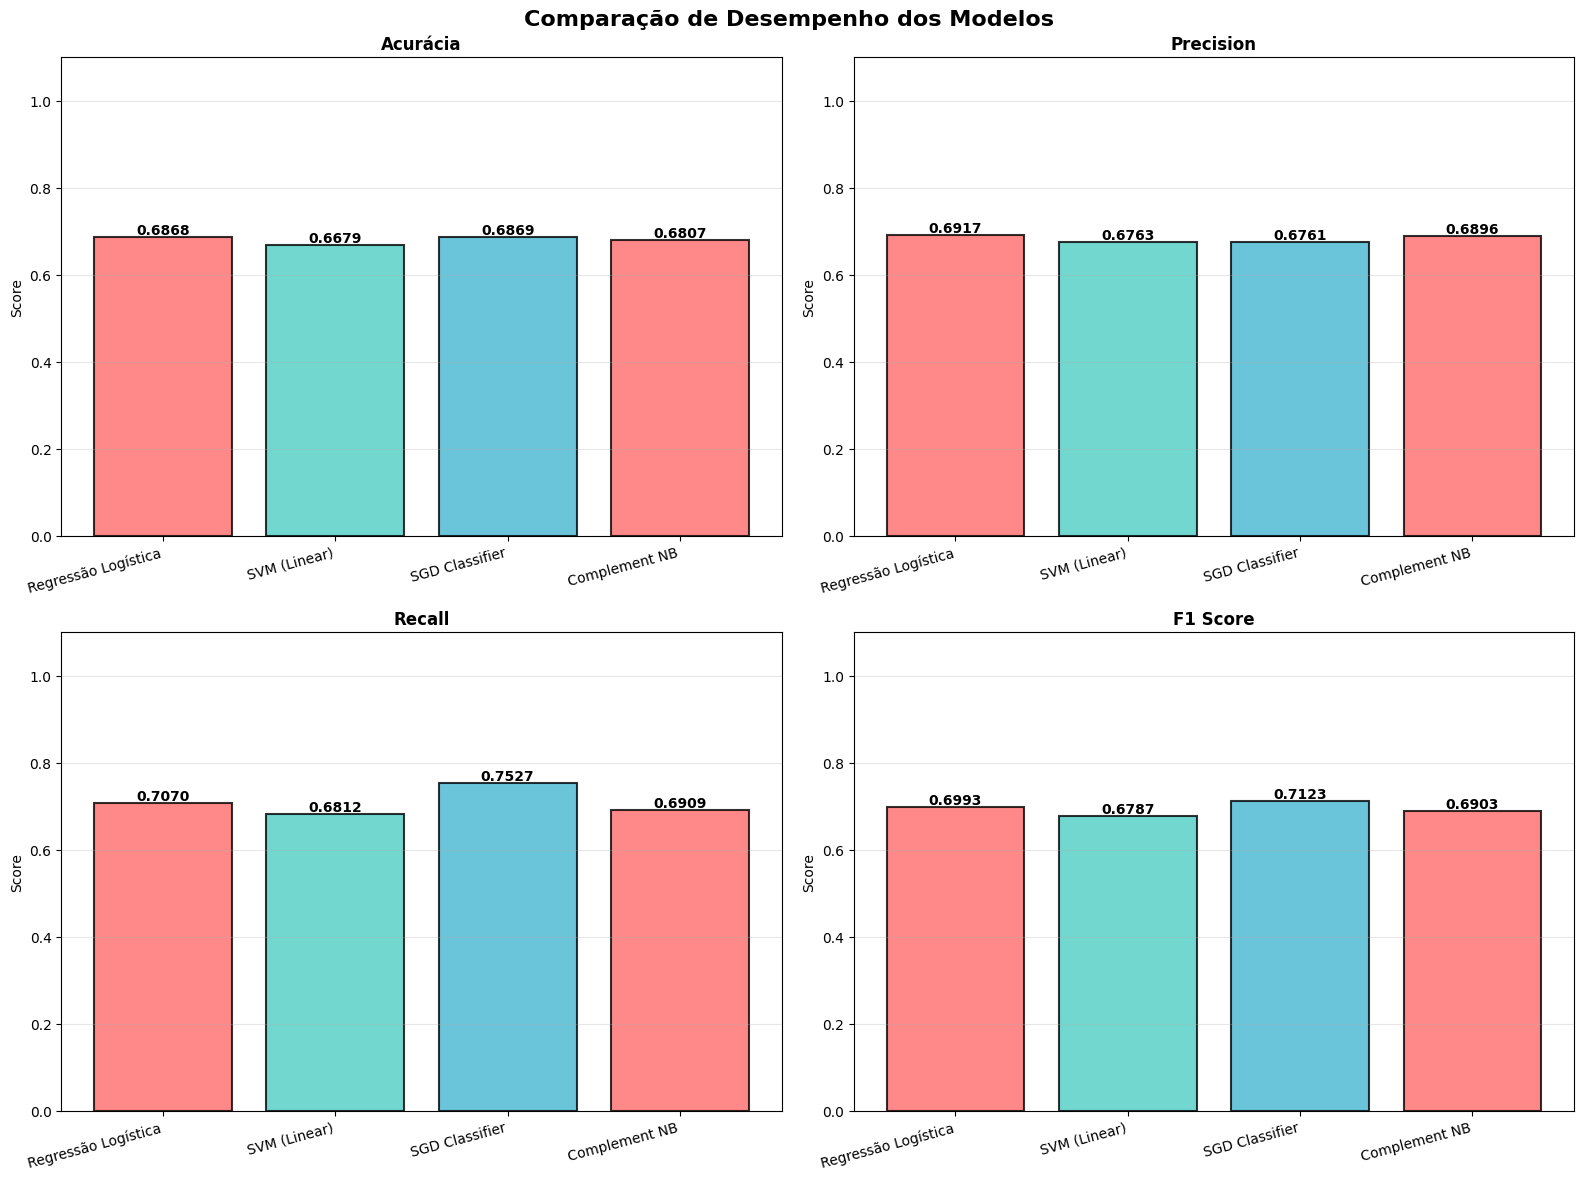

Gráfico de comparação exibido!


In [17]:
# Visualização de comparação
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparação de Desempenho dos Modelos', fontsize=16, fontweight='bold')

metrics = ['Acurácia', 'Precision', 'Recall', 'F1 Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metric].values
    bars = ax.bar(comparison_df['Modelo'], values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

print('Gráfico de comparação exibido!')

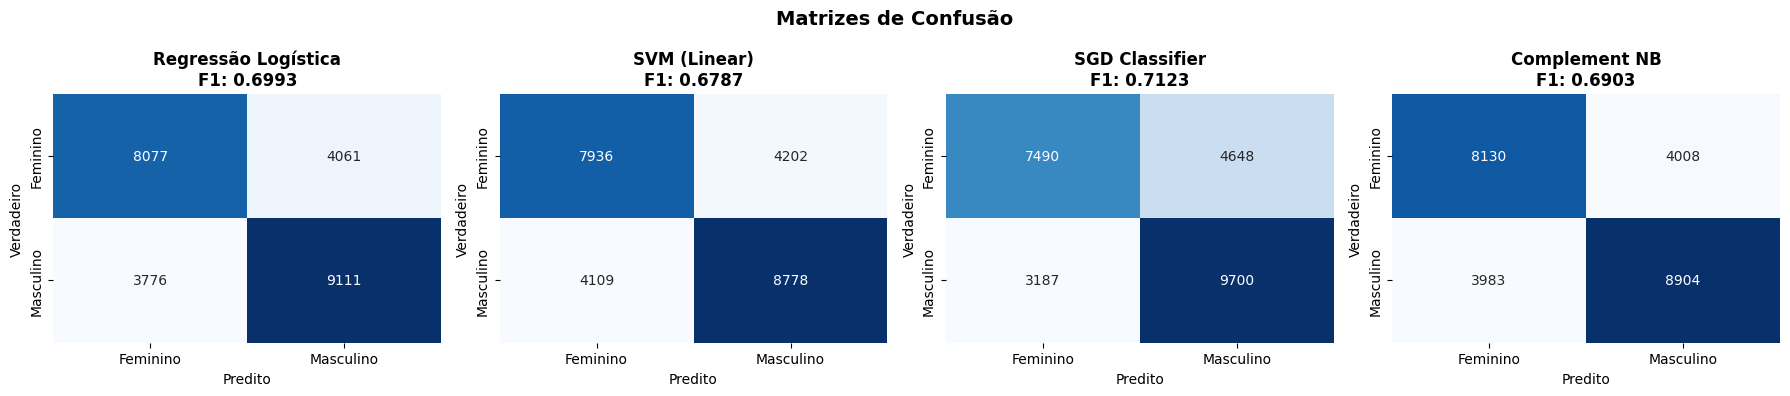

In [18]:
# Visualizar matrizes de confusão
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Matrizes de Confusão', fontsize=14, fontweight='bold')

confusao_matrices = {
    'Regressão Logística': cm_lr,
    'SVM (Linear)': cm_svm,
    'SGD Classifier': cm_sgd,
    'Complement NB': cm_cnb,
}

for idx, (nome, cm) in enumerate(confusao_matrices.items()):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Feminino', 'Masculino'],
                yticklabels=['Feminino', 'Masculino'],
                cbar=False)
    ax.set_title(f'{nome}\nF1: {resultados[nome]["f1"]:.4f}', fontweight='bold')
    ax.set_ylabel('Verdadeiro')
    ax.set_xlabel('Predito')

plt.tight_layout()
plt.show()

## 10. Pipeline e Serialização do Melhor Modelo

In [20]:
class GenderClassificationPipeline:
    """Pipeline completo de classificação de gênero."""

    def __init__(self, preprocessor, vectorizer, model):
        self.preprocessor = preprocessor
        self.vectorizer = vectorizer
        self.model = model

    def preprocess(self, text):
        return self.preprocessor(text)

    def predict(self, texts):
        if isinstance(texts, str):
            texts = [texts]

        texts_processados = [self.preprocess(t) for t in texts]
        X = self.vectorizer.transform(texts_processados)

        if hasattr(X, 'toarray'):
            try:
                X = X.toarray()
            except:
                pass

        predictions = self.model.predict(X)
        return predictions

    def predict_proba(self, texts):
        if isinstance(texts, str):
            texts = [texts]

        texts_processados = [self.preprocess(t) for t in texts]
        X = self.vectorizer.transform(texts_processados)

        if hasattr(X, 'toarray'):
            try:
                X = X.toarray()
            except:
                pass

        if hasattr(self.model, 'predict_proba'):
            return self.model.predict_proba(X)
        else:
            return self.model.decision_function(X)

# Criar pipeline com o melhor modelo
melhor_modelo_nome = 'Regressão Logística'
melhor_modelo_obj = resultados[melhor_modelo_nome]['model']
pipeline = GenderClassificationPipeline(
    preprocessor=preprocessar_texto,
    vectorizer=tfidf_vectorizer,
    model=melhor_modelo_obj
)

print(f'\nPipeline criado com {melhor_modelo_nome}!')


Pipeline criado com Regressão Logística!


In [21]:

teste_textos = [
    "Adorei este produto! Superou minhas expectativas, recomendo muito!",
    "Produto ruim, não funciona como prometido. Péssima qualidade.",
    "Entrega rápida, produto conforme esperado. Satisfeito com a compra."
]

for texto in teste_textos:
    pred = pipeline.predict(texto)[0]
    genero = "Masculino (M)" if pred == 1 else "Feminino (F)"
    print(f"\nTexto: {texto[:50]}...")
    print(f"Predição: {genero}")




Texto: Adorei este produto! Superou minhas expectativas, ...
Predição: Feminino (F)

Texto: Produto ruim, não funciona como prometido. Péssima...
Predição: Masculino (M)

Texto: Entrega rápida, produto conforme esperado. Satisfe...
Predição: Masculino (M)


In [22]:
# Salvar o modelo em pickle
nome_arquivo = "modelo_izabella_catrinck.pkl"

with open(nome_arquivo, 'wb') as f:
    pickle.dump(pipeline, f)

print(f"\nMODELO SALVO COM SUCESSO!")
print(f"   Arquivo: {nome_arquivo}")
print(f"   Tamanho: {Path(nome_arquivo).stat().st_size / 1024:.2f} KB")

print(f"   Nome: {melhor_modelo_nome}")
print(f"   Acurácia: {resultados[melhor_modelo_nome]['accuracy']:.4f}")
print(f"   Precision: {resultados[melhor_modelo_nome]['precision']:.4f}")
print(f"   Recall: {resultados[melhor_modelo_nome]['recall']:.4f}")
print(f"   F1 Score: {resultados[melhor_modelo_nome]['f1']:.4f}")
print(f"   ROC-AUC: {resultados[melhor_modelo_nome]['auc']:.4f}")


MODELO SALVO COM SUCESSO!
   Arquivo: modelo_izabella_catrinck.pkl
   Tamanho: 1887.81 KB
   Nome: Regressão Logística
   Acurácia: 0.6868
   Precision: 0.6917
   Recall: 0.7070
   F1 Score: 0.6993
   ROC-AUC: 0.7597


## 11. Verificação do Modelo Salvo

In [23]:
with open(nome_arquivo, 'rb') as f:
    modelo_carregado = pickle.load(f)
y_pred_verificacao = np.array([modelo_carregado.predict(texto)[0] for texto in X_val[:100]])
acc_verificacao = accuracy_score(y_val[:100], y_pred_verificacao)
f1_verificacao = f1_score(y_val[:100], y_pred_verificacao)

print(f"\nAmostra de 100 validações:")
print(f"  Acurácia: {acc_verificacao:.4f}")
print(f"  F1 Score: {f1_verificacao:.4f}")


Amostra de 100 validações:
  Acurácia: 0.7400
  F1 Score: 0.7759
